# Search Key Relevance Prediction Analysis

This notebook analyzes the results of our relevance prediction model for search keywords related to organ transplantation.

## Overview
- **Input**: Search keywords from Google Autocomplete and Google Trends
- **Model**: Trained relevance prediction model
- **Output**: Binary classification (0 = Not Relevant, 1 = Relevant)
- **Focus**: Visualization and analysis of prediction results


In [8]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [9]:
# Load the prediction results
df = pd.read_csv('../data/search key/raw/predicted_search_key_combined_cleaned.csv')

print("Dataset Overview:")
print(f"Total search keywords: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nTransplant types: {df['type'].unique()}")
print(f"\nRelevance distribution:")
print(df['predicted_relevance'].value_counts())

df.head()


Dataset Overview:
Total search keywords: 1239
Columns: ['search key', 'type', 'source', 'cluster_id', 'variants', 'predicted_relevance']

Transplant types: ["['lung transplant']" "['heart transplant']" "['kidney transplant']"
 "['heart-lung transplant']" "['pancreas transplant']"
 "['liver transplant']"]

Relevance distribution:
predicted_relevance
1    1058
0     181
Name: count, dtype: int64


,search key,type,source,cluster_id,variants,predicted_relevance
0,lung transplant rejection,['lung transplant'],google_complete,0,"['lung transplant rejection after 5 years', 'l...",1
1,lung transplant history,['lung transplant'],google_complete,1,"['lung transplant last', 'lung transplant time...",1
2,heart transplant rejection,['heart transplant'],google_complete,2,"['heart transplant rejection stages', 'heart t...",1
3,kidney transplant hospitals in florida,['kidney transplant'],google_complete,3,['kidney transplant tampa general hospital'],1
4,heart lung transplant uk,['heart-lung transplant'],google_complete,4,"['first heart lung transplant uk', 'heart and ...",1


## 1. Overall Relevance Distribution


Relevance Prediction Results:
Relevant keywords: 1058 (85.4%)
Not relevant keywords: 181 (14.6%)


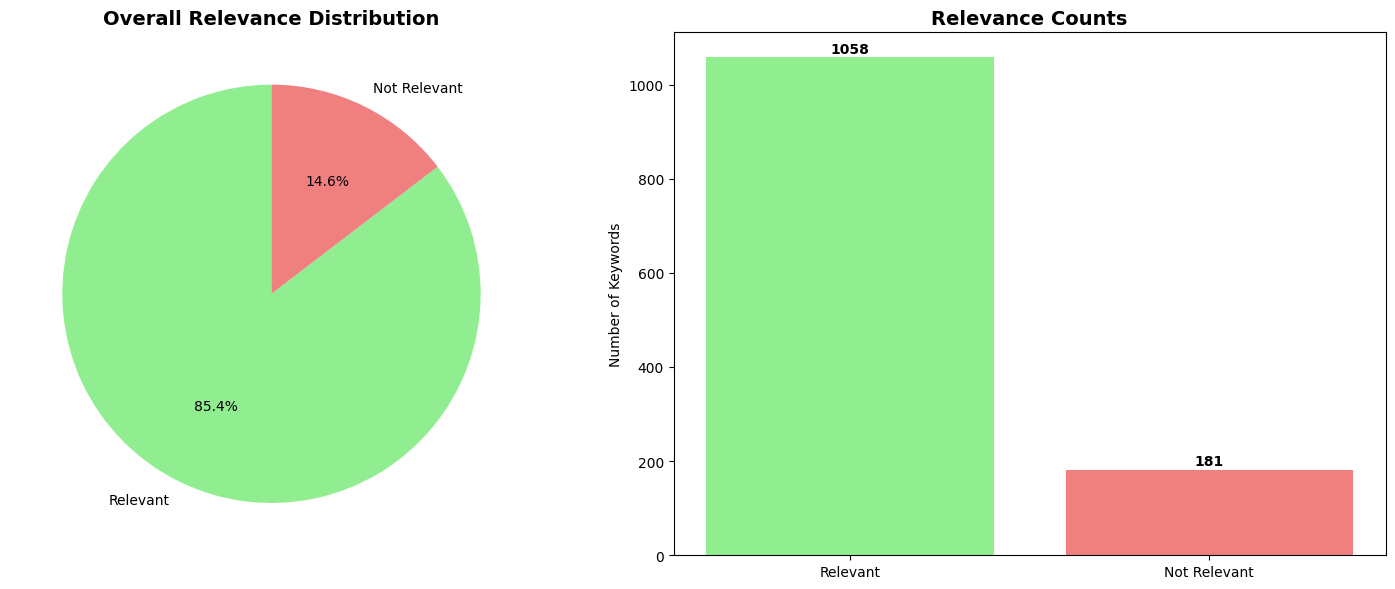

In [10]:
# Overall relevance statistics
relevant_count = df['predicted_relevance'].sum()
not_relevant_count = len(df) - relevant_count
relevance_rate = relevant_count / len(df)

print(f"Relevance Prediction Results:")
print(f"Relevant keywords: {relevant_count} ({relevance_rate:.1%})")
print(f"Not relevant keywords: {not_relevant_count} ({1-relevance_rate:.1%})")

# Simple pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
labels = ['Relevant', 'Not Relevant']
sizes = [relevant_count, not_relevant_count]
colors = ['lightgreen', 'lightcoral']

ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Overall Relevance Distribution', fontsize=14, fontweight='bold')

# Bar chart
ax2.bar(labels, sizes, color=colors)
ax2.set_title('Relevance Counts', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Keywords')

for i, v in enumerate(sizes):
    ax2.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 2. Relevance by Transplant Type


Relevance Analysis by Transplant Type:
                           Total  Relevant_Count  Relevance_Rate  \
type                                                               
['lung transplant']          241             223           0.925   
['heart-lung transplant']     65              59           0.908   
['kidney transplant']        298             265           0.889   
['pancreas transplant']      110              94           0.855   
['liver transplant']         262             222           0.847   
['heart transplant']         263             195           0.741   

                           Not_Relevant_Count  
type                                           
['lung transplant']                        18  
['heart-lung transplant']                   6  
['kidney transplant']                      33  
['pancreas transplant']                    16  
['liver transplant']                       40  
['heart transplant']                       68  


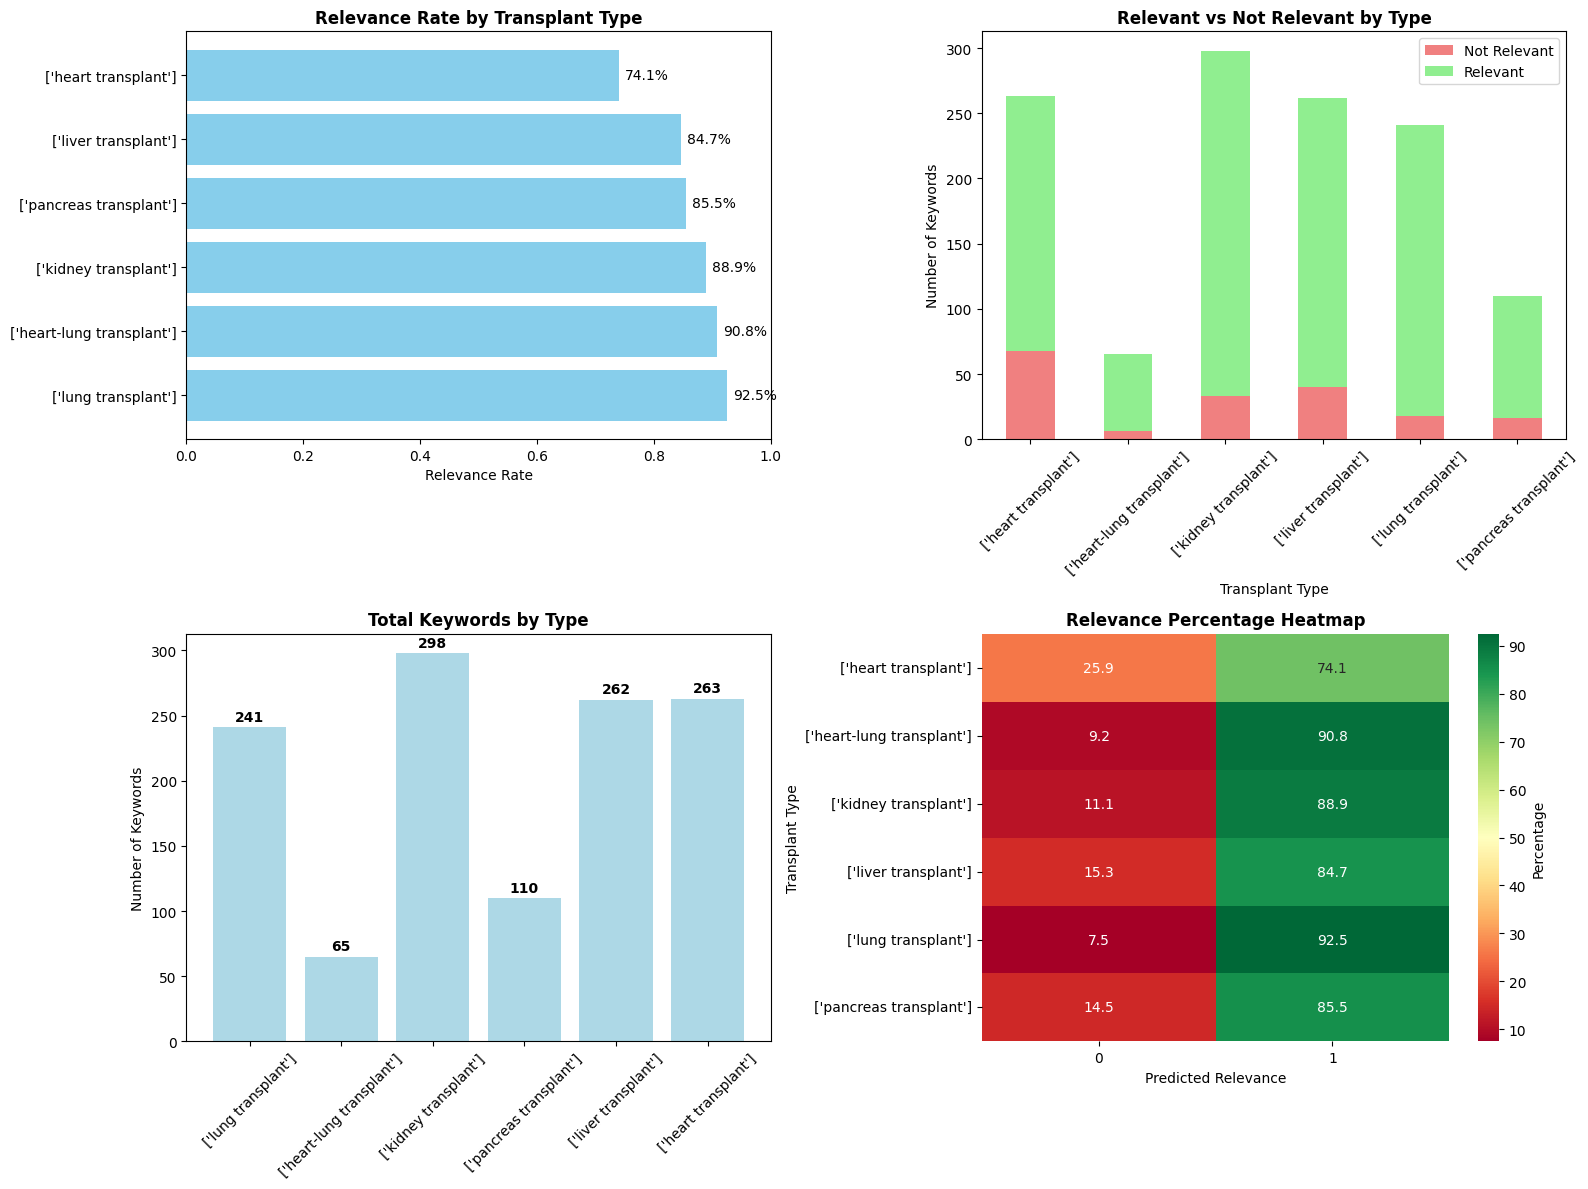

In [11]:
# Analyze relevance by transplant type
type_analysis = df.groupby('type')['predicted_relevance'].agg(['count', 'sum', 'mean']).round(3)
type_analysis.columns = ['Total', 'Relevant_Count', 'Relevance_Rate']
type_analysis['Not_Relevant_Count'] = type_analysis['Total'] - type_analysis['Relevant_Count']
type_analysis = type_analysis.sort_values('Relevance_Rate', ascending=False)

print("Relevance Analysis by Transplant Type:")
print(type_analysis)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Relevance rate by type (horizontal bar)
axes[0,0].barh(type_analysis.index, type_analysis['Relevance_Rate'], color='skyblue')
axes[0,0].set_title('Relevance Rate by Transplant Type', fontweight='bold')
axes[0,0].set_xlabel('Relevance Rate')
axes[0,0].set_xlim(0, 1)

# Add percentage labels
for i, v in enumerate(type_analysis['Relevance_Rate']):
    axes[0,0].text(v + 0.01, i, f'{v:.1%}', va='center')

# 2. Stacked bar chart
type_counts = df.groupby(['type', 'predicted_relevance']).size().unstack(fill_value=0)
type_counts.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'], ax=axes[0,1])
axes[0,1].set_title('Relevant vs Not Relevant by Type', fontweight='bold')
axes[0,1].set_xlabel('Transplant Type')
axes[0,1].set_ylabel('Number of Keywords')
axes[0,1].legend(['Not Relevant', 'Relevant'])
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Total keywords by type
axes[1,0].bar(type_analysis.index, type_analysis['Total'], color='lightblue')
axes[1,0].set_title('Total Keywords by Type', fontweight='bold')
axes[1,0].set_ylabel('Number of Keywords')
axes[1,0].tick_params(axis='x', rotation=45)

# Add count labels
for i, v in enumerate(type_analysis['Total']):
    axes[1,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 4. Relevance rate heatmap
heatmap_data = df.groupby(['type', 'predicted_relevance']).size().unstack(fill_value=0)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Relevance Percentage Heatmap', fontweight='bold')
axes[1,1].set_xlabel('Predicted Relevance')
axes[1,1].set_ylabel('Transplant Type')

plt.tight_layout()
plt.show()


## 3. Export Results with Clean File Structure


In [12]:
# Export relevant and not relevant keywords separately
output_dir = '../data/search key/relevance_predicted_results/results'
os.makedirs(output_dir, exist_ok=True)

# Export overall results
relevant_df = df[df.predicted_relevance == 1][['type', 'search key']]
not_relevant_df = df[df.predicted_relevance == 0][['type', 'search key']]

relevant_df.to_csv(f'{output_dir}/relevant_keywords.csv', index=False)
not_relevant_df.to_csv(f'{output_dir}/not_relevant_keywords.csv', index=False)

print(f"Exported {len(relevant_df)} relevant keywords to: {output_dir}/relevant_keywords.csv")
print(f"Exported {len(not_relevant_df)} not relevant keywords to: {output_dir}/not_relevant_keywords.csv")


Exported 1058 relevant keywords to: ../data/search key/relevance_predicted_results/results/relevant_keywords.csv
Exported 181 not relevant keywords to: ../data/search key/relevance_predicted_results/results/not_relevant_keywords.csv


In [13]:
# Export by transplant type with clean naming
type_output_dir = f'{output_dir}/by_type'
os.makedirs(type_output_dir, exist_ok=True)

print("Exporting keywords by transplant type:")
print("=" * 50)

for type_name in df['type'].unique():
    type_data = df[df['type'] == type_name]
    
    # Clean type name for filename
    clean_type_name = type_name.replace(' ', '_').replace('-', '_')
    
    # Export relevant keywords
    relevant_type = type_data[type_data.predicted_relevance == 1][['search key']]
    relevant_filename = f"{clean_type_name}_relevant.csv"
    relevant_path = os.path.join(type_output_dir, relevant_filename)
    relevant_type.to_csv(relevant_path, index=False)
    
    # Export not relevant keywords
    not_relevant_type = type_data[type_data.predicted_relevance == 0][['search key']]
    not_relevant_filename = f"{clean_type_name}_not_relevant.csv"
    not_relevant_path = os.path.join(type_output_dir, not_relevant_filename)
    not_relevant_type.to_csv(not_relevant_path, index=False)
    
    print(f"{type_name}:")
    print(f"  Relevant: {len(relevant_type)} keywords -> {relevant_filename}")
    print(f"  Not relevant: {len(not_relevant_type)} keywords -> {not_relevant_filename}")
    print()

print(f"All files saved to: {type_output_dir}")


Exporting keywords by transplant type:
['lung transplant']:
  Relevant: 223 keywords -> ['lung_transplant']_relevant.csv
  Not relevant: 18 keywords -> ['lung_transplant']_not_relevant.csv

['heart transplant']:
  Relevant: 195 keywords -> ['heart_transplant']_relevant.csv
  Not relevant: 68 keywords -> ['heart_transplant']_not_relevant.csv

['kidney transplant']:
  Relevant: 265 keywords -> ['kidney_transplant']_relevant.csv
  Not relevant: 33 keywords -> ['kidney_transplant']_not_relevant.csv

['heart-lung transplant']:
  Relevant: 59 keywords -> ['heart_lung_transplant']_relevant.csv
  Not relevant: 6 keywords -> ['heart_lung_transplant']_not_relevant.csv

['pancreas transplant']:
  Relevant: 94 keywords -> ['pancreas_transplant']_relevant.csv
  Not relevant: 16 keywords -> ['pancreas_transplant']_not_relevant.csv

['liver transplant']:
  Relevant: 222 keywords -> ['liver_transplant']_relevant.csv
  Not relevant: 40 keywords -> ['liver_transplant']_not_relevant.csv

All files saved 

## 4. Summary Statistics


In [14]:
# Generate summary report
print("RELEVANCE PREDICTION SUMMARY REPORT")
print("=" * 50)
print(f"Total search keywords analyzed: {len(df)}")
print(f"Overall relevance rate: {relevance_rate:.1%}")
print(f"Relevant keywords: {relevant_count}")
print(f"Not relevant keywords: {not_relevant_count}")
print()

print("By Transplant Type:")
for type_name in type_analysis.index:
    type_data = df[df['type'] == type_name]
    type_relevant = type_data['predicted_relevance'].sum()
    type_total = len(type_data)
    type_rate = type_relevant / type_total
    
    print(f"  {type_name}: {type_relevant}/{type_total} ({type_rate:.1%})")

print()
print("Files exported:")
print(f"  - Overall results: {output_dir}/relevant_keywords.csv, {output_dir}/not_relevant_keywords.csv")
print(f"  - By type: {type_output_dir}/")
print("\nAnalysis complete!")


RELEVANCE PREDICTION SUMMARY REPORT
Total search keywords analyzed: 1239
Overall relevance rate: 85.4%
Relevant keywords: 1058
Not relevant keywords: 181

By Transplant Type:
  ['lung transplant']: 223/241 (92.5%)
  ['heart-lung transplant']: 59/65 (90.8%)
  ['kidney transplant']: 265/298 (88.9%)
  ['pancreas transplant']: 94/110 (85.5%)
  ['liver transplant']: 222/262 (84.7%)
  ['heart transplant']: 195/263 (74.1%)

Files exported:
  - Overall results: ../data/search key/relevance_predicted_results/results/relevant_keywords.csv, ../data/search key/relevance_predicted_results/results/not_relevant_keywords.csv
  - By type: ../data/search key/relevance_predicted_results/results/by_type/

Analysis complete!


## File Structure

The analysis creates the following organized file structure:

```
data/search key/
├── raw/                                    # Raw data files
│   ├── search_key_combined_unclean.csv     # Original combined data
│   ├── search_key_combined_cleaned.csv     # Cleaned data
│   └── predicted_search_key_combined_cleaned.csv  # Data with predictions
└── relevance_predicted_results/                               # Analysis results
    ├── relevant_keywords.csv              # All relevant keywords
    ├── not_relevant_keywords.csv          # All not relevant keywords
    └── by_type/                           # Results by transplant type
        ├── heart_transplant_relevant.csv
        ├── heart_transplant_not_relevant.csv
        ├── kidney_transplant_relevant.csv
        ├── kidney_transplant_not_relevant.csv
        ├── liver_transplant_relevant.csv
        ├── liver_transplant_not_relevant.csv
        ├── lung_transplant_relevant.csv
        ├── lung_transplant_not_relevant.csv
        ├── pancreas_transplant_relevant.csv
        ├── pancreas_transplant_not_relevant.csv
        ├── heart_lung_transplant_relevant.csv
        └── heart_lung_transplant_not_relevant.csv
```

This structure provides:
- **Clean file naming** (no brackets or special characters)
- **Logical organization** (raw data vs results)
- **Easy access** to both overall and type-specific results
- **GitHub-friendly** structure for sharing
